In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
import random
import joblib

In [2]:
TRA = pd.read_csv("Data/Training_Data.csv")

In [3]:
TRA

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos,Race_Result
0,ALB,83.130,81.847,81.664,100.398929,80.941,15.0,12.0
1,ANT,81.376,79.943,80.324,95.665077,78.811,2.0,2.0
2,BEA,82.682,81.326,80.778,102.072750,80.311,12.0,7.0
3,BOR,81.696,81.668,80.459,99.549182,80.221,10.0,9.0
4,BOT,84.022,83.660,83.514,101.500360,83.244,19.0,19.0
...,...,...,...,...,...,...,...,...
78,PIA,89.758,88.108,92.079,111.682429,88.500,7.0,3.0
79,RUS,90.100,88.493,92.387,106.589556,88.197,5.0,4.0
80,SAI,90.930,90.224,94.008,111.177600,89.568,13.0,9.0
81,STR,92.959,91.043,95.009,125.395000,91.164,18.0,17.0


In [12]:
X = TRA.iloc[:,1:-1]

In [13]:
X

,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos
0,83.130,81.847,81.664,100.398929,80.941,15.0
1,81.376,79.943,80.324,95.665077,78.811,2.0
2,82.682,81.326,80.778,102.072750,80.311,12.0
3,81.696,81.668,80.459,99.549182,80.221,10.0
4,84.022,83.660,83.514,101.500360,83.244,19.0
...,...,...,...,...,...,...
78,89.758,88.108,92.079,111.682429,88.500,7.0
79,90.100,88.493,92.387,106.589556,88.197,5.0
80,90.930,90.224,94.008,111.177600,89.568,13.0
81,92.959,91.043,95.009,125.395000,91.164,18.0


In [14]:
y = TRA.iloc[:,-1]

In [15]:
imputer = SimpleImputer(strategy="median")

In [16]:
X_imputed = imputer.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y, test_size = 0.2, random_state = 23)

In [20]:
model = RandomForestRegressor()

In [21]:
parameter ={
    'n_estimators': [20,25,50,70,75,100],
    'max_samples' :[3,4,5,6,7,8,9,10]
}

In [22]:
regcv = GridSearchCV(model, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')

In [23]:
regcv.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_samples': [3, 4, ...], 'n_estimators': [20, 25, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,25


In [24]:
y_pred = regcv.predict(X_test)

In [27]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.6095765421126293


In [36]:
count = 0
while(True):
    count += 1
    r = random.randint(0,45)
    X_train, X_test, y_train, y_test = train_test_split(X_imputed , y, test_size = 0.2, random_state = r)
    model = RandomForestRegressor()
    parameter ={
        'n_estimators': [20,25,50,70,75,100],
        'max_samples' :[3,4,5,6,7,8,9,10]
    }
    regcv = GridSearchCV(model, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')
    regcv.fit(X_train, y_train)
    y_pred = regcv.predict(X_test)
    corr, _ = spearmanr(y_pred, y_test)

    print(f"{count}. Spearman Rank:{corr}, Random Value:{r} \n")

    if corr > 0.85:
        break
    

1. Spearman Rank:0.9244051026946802, Random Value:20 



In [37]:
corr, _ = spearmanr(y_pred, y_test)
print(corr)

0.9244051026946802


In [41]:
joblib.dump(regcv, 'Model/RandomForestModel92.pkl')

['Model/RandomForestModel92.pkl']

In [42]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

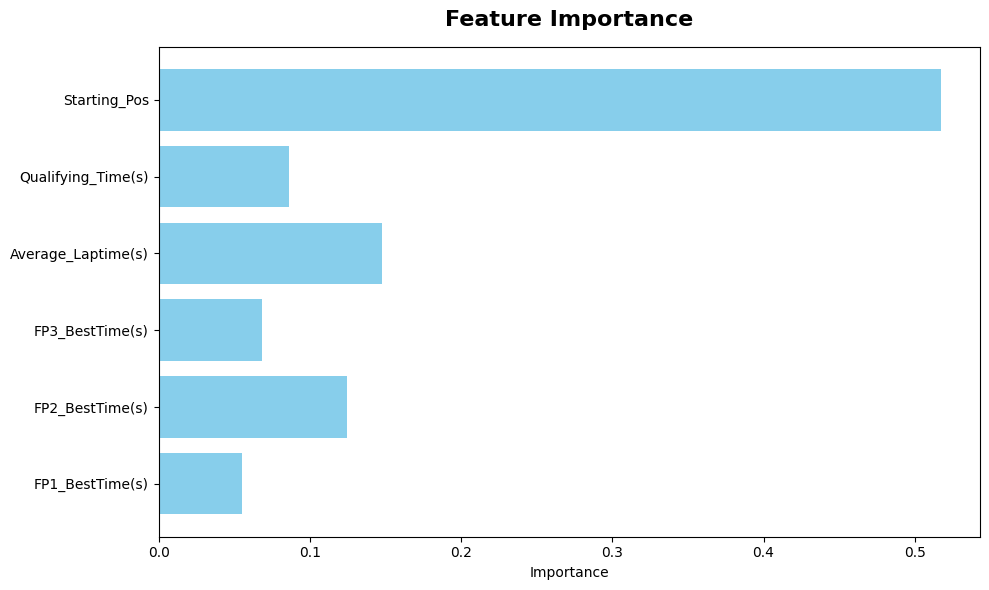

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Plots/Feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()